# This is a rough draft of my general workflow for Mini-Project 1

## Step 1: Load in the data and inspect it 

# From the data source we have a sort description of each dataset: 
- data.csv: "All of the text written/generated from the various different sources"
    - this is the main corpus: what the whole project will be built on 
- distribution.csv: "The distribution of data across all the different sources"
    - this will be useful for the preliminary corpus statistics section 
        - will tell us how many texts came from each source (i.e., which LLMs are represented int he data, how much of the data is human, etc.) without having to load all 800k rows 
- prompts.csv : "All the prompts/topics used for the writing/generation of all the text in data.csv/data.parquet"
    - could be interesting for context of the text in data.csv but not central to the analysis 
        - might be nice to look at just to know what prompts were used (help with some choices I make or limitations I discuss)

In [3]:
import pandas as pd
import os 

# Build path relative to this notebook's location
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
data_dir = os.path.join(notebook_dir, '..', 'data')

# read in just the first 3 rows of each dataset to take a look
for fname in ['data.csv', 'distribution.csv', 'prompts.csv']:
    df = pd.read_csv(os.path.join(data_dir, fname), nrows=3)
    print(f"\n=== {fname} ===")
    print(f"Columns: {df.columns.tolist()}")
    print(df.head(3))


=== data.csv ===
Columns: ['text', 'source', 'prompt_id', 'text_length', 'word_count']
                                                text    source  prompt_id  \
0  Federal law supersedes state law, and cannabis...  Bloom-7B          0   
1  Miles feels restless after working all day. He...  Bloom-7B          0   
2  So first of I am danish. That means that I fol...  Bloom-7B          0   

   text_length  word_count  
0          967         157  
1         5068         778  
2         1602         267  

=== distribution.csv ===
Columns: ['Source', 'Number of Samples', 'Percentage of Total Data', 'Text Length Sum', 'Text Length Mean', 'Text Length Median', 'Text Length Std', 'Text Length Max', 'Text Length Min', 'Word Count Sum', 'Word Count Mean', 'Word Count Median', 'Word Count Std', 'Word Count Max', 'Word Count Min']
             Source  Number of Samples Percentage of Total Data  \
0             Human             347692                 44.0718%   
1           GPT-3.5         

## From this output we've learned: 
- data.csv has the columns we'll need: 
    - text: is the corpus
    - source: the label (not just Human/LLM binary, but the actual model name like Bloom-7B, GPT-3.5, etc.)
    - prompt_id links to the prompts file, and text_length/word_count are pre-computed which is nice for corpus statistics.
- distribution.csv provides various summary statistics 
- prompts.csv tells us the writing prompts
    - prompt 0 is "Undefined" (some texts had no specific prompt)

### From this my two ideas for classifications methods are either
- Option A: Binary classification human (0) vs. All LLMs combined (1)
- Option B: Multi-classification: human vs (the different AI models: vs. GPT-3.5 vs. Bloom-7B vs. Text-Davinci-003 vs. ...)

### To better inform my decision on a classification method, I will explore the number of unique datasources 


In [4]:
# Load full distribution to see all sources
dist_df = pd.read_csv(os.path.join(data_dir, 'distribution.csv'))
print(dist_df[['Source', 'Number of Samples', 'Percentage of Total Data']])

                      Source  Number of Samples Percentage of Total Data
0                      Human             347692                 44.0718%
1                    GPT-3.5              52346                  6.6351%
2           Text-Davinci-003              22860                  2.8976%
3           Text-Davinci-002              21436                  2.7171%
4                   OPT-1.3B              18467                  2.3408%
..                       ...                ...                      ...
58                Toppy-M-7B                433                  0.0549%
59                LLaMA-2-7B                409                  0.0518%
60      Dolphin-Mixtral-8x7B                407                  0.0516%
61            Cohere-Command                390                  0.0494%
62  Dolphin-2.5-Mixtral-8x7B                228                  0.0289%

[63 rows x 3 columns]


### Based on my general purpose for this analysis I will do binary classification, as I think the general human vs. AI difference is more interesting/better aligns with the goal of my study 
### Overall: the more interesting question isn't if we can tell a difference between LLMs... its the general question: ("can we tell human writing from machine writing at all") = more culturally meaningful
- Further supporting this decision is the output above: 
    - There are 63 sources total (62 LLMs + humans), and many of the LLMs have tiny sample sizes so if I tried to do multi-class classification between all the different LLMs - most would end up so small that the later model wouldn't learn anything meaningful from them  
- Human vs. AI is more balanced (~347K human texts. vs ~441K AI texts)

# <span style="color: red;">FOR LATER WRITEUP- Limitation</span>
- The AI side (of the binary classification) is actually an aggregation of very different models (GPT family, Bloom, etc.) which vary a lot in quality and style. 
    - Worth flagging as a limitation — "AI writing" isn't monolithic, and collapsing 62 models into one label introduces heterogeneity that could affect both classification and topic modeling results.

# <span style="color: blue;">1st Main Step: Load and Sample the Data</span>
- Because data.csv is 800k rows (that would take a lot of RAM), I will load in a reproducible random sample (~10,000 rows)
- Will also create the binary label in this step where (Human=0, all others(LLM's) = 1)

In [5]:
import numpy as np

# configuration step
    # defining key parameters for sampling 
SAMPLE_SIZE = 10000
RANDOM_SEED = 230   # setting a random seed for reproducibility (can be anything - INFO 230 - for fun!)

# using os path for reproducibility on another machine 
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
data_dir = os.path.join(notebook_dir, '..', 'data')

# First loading in full dataset then immediately taking a random sample to keep computation manageable
print("Loading data.csv...")
ai_human_df = pd.read_csv(os.path.join(data_dir, 'data.csv'))
print(f"Full dataset size: {len(ai_human_df):,} rows")

# Reproducible random sample
ai_human_df_sample = ai_human_df.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)
print(f"Sample size: {len(ai_human_df_sample):,} rows")

# Create the binary label 
    # original data had 62+ unique LLM names plus 'human' 
    # binary classification simplify this to: 
        # Human = 0, all LLMs = 1

ai_human_df_sample['label'] = (ai_human_df_sample['source'] != 'Human').astype(int)

print(f"\nLabel distribution in sample:")
print(ai_human_df_sample['label'].value_counts().rename({0: 'Human', 1: 'AI'}))
print(f"\nSample preview:")
ai_human_df_sample[['text', 'source', 'label', 'word_count']].head(3)

Loading data.csv...
Full dataset size: 788,922 rows
Sample size: 10,000 rows

Label distribution in sample:
label
AI       5548
Human    4452
Name: count, dtype: int64

Sample preview:


,text,source,label,word_count
0,Oxygen gas (O 2) can be toxic at elevated part...,Human,0,105
1,The Tortoise and the Rabbit: A Story of Determ...,Mistral-7B,1,401
2,"When we write words from another language, lik...",Text-Davinci-003,1,68


### Sanity check confirmed but output above 
- Label distribution in sample: 
    - 5,548 AI vs 4,452 Human (55.5% / 44.5%) : closely aligns with the full dataset's distribution reflected in the above quick look at ```distribution.csv``` file 
        - MEANING: this is a good random sample 
        - classes are also pretty balanced: good for classification 

### Previewing the sample: 
- we can see the variety of sources as well as varying word counts: which hints to me that text length variability may be interesting to explore in the next step

# <span style="color: blue;">Step 2: Preliminary corpus Statistic</span>

- Before modeling lets do some EDA (exploratory data analysis) to better understand the basic properties of this corpus 
    - Including: document counts, label balance, and text length distributions 
- I will use both the sample loaded in the previous step AND the pre-computed distribution.csv file provided for full-dataset stats

### Part 1: Computing stats directly from my sample 

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Part 1: Sample-level Stats
print("===CORPUS STATISTICS===")

print(f"\n ---Document Counts---")
print(f"\t Full dataset: {len(ai_human_df):>10,} documents")
print(f"\t Working sample: {len(ai_human_df_sample):>10,} documents")
print(f"\t Sample fraction: {len(ai_human_df_sample)/len(ai_human_df)*100:.2f}% of full corpus")

print(f"\n ---Label Distribution (Sample)---")
label_counts = ai_human_df_sample['label'].value_counts().rename({0: 'Human', 1: 'AI'})
label_pcts   = ai_human_df_sample['label'].value_counts(normalize=True).rename({0: 'Human', 1: 'AI'}) * 100
for label in ['Human', 'AI']:
    print(f"\t {label:<8} {label_counts[label]:>6,} documents  ({label_pcts[label]:.1f}%)")

print(f"\n ---Text Length Statistics (Sample, in words)---")
for label_name, label_val in [('Human', 0), ('AI', 1)]:
    subset = ai_human_df_sample[ai_human_df_sample['label'] == label_val]['word_count']
    print(f"\n  {label_name}:")
    print(f"\t Mean: {subset.mean():.1f} words")
    print(f"\t Median: {subset.median():.1f} words")
    print(f"\t Stdev: {subset.std():.1f} words")
    print(f"\t Min: {subset.min()} words")
    print(f"\t Max: {subset.max()} words")

print(f"\n ---Vocabulary Size (Sample)---")
# Approximate vocabulary: all unique whitespace-separated tokens across the sample
all_words = ai_human_df_sample['text'].str.lower().str.split().explode()
print(f"\t Unique tokens (raw):  {all_words.nunique():,}")

===CORPUS STATISTICS===

 ---Document Counts---
	 Full dataset:    788,922 documents
	 Working sample:     10,000 documents
	 Sample fraction: 1.27% of full corpus

 ---Label Distribution (Sample)---
	 Human     4,452 documents  (44.5%)
	 AI        5,548 documents  (55.5%)

 ---Text Length Statistics (Sample, in words)---

  Human:
	 Mean: 700.8 words
	 Median: 386.5 words
	 Stdev: 1022.8 words
	 Min: 25 words
	 Max: 23392 words

  AI:
	 Mean: 335.9 words
	 Median: 283.0 words
	 Stdev: 279.3 words
	 Min: 25 words
	 Max: 5019 words

 ---Vocabulary Size (Sample)---
	 Unique tokens (raw):  185,152


### Part 2: Get the stats on the full dataset from distribution.csv 
- Important for my brief report: as the sample only uses 1.3% of the corpus

In [7]:
# Part 2: Full Dataset Stats (pulled from distribution.csv)
    # distribution.csv has pre-computed stats for all 788k documents 
    # can use this to give an accurate picture of the full corpus in the writeup
print(f"\n── Full Dataset Source Distribution (from distribution.csv) ──")
dist_df = pd.read_csv(os.path.join(data_dir, 'distribution.csv'))
print(dist_df[['Source', 'Number of Samples', 'Percentage of Total Data',
               'Word Count Mean', 'Word Count Median']].to_string(index=False))



── Full Dataset Source Distribution (from distribution.csv) ──
                   Source  Number of Samples Percentage of Total Data  Word Count Mean  Word Count Median
                    Human             347692                 44.0718%          710.335              396.0
                  GPT-3.5              52346                  6.6351%          432.380              505.0
         Text-Davinci-003              22860                  2.8976%          156.798              121.0
         Text-Davinci-002              21436                  2.7171%          159.292              107.0
                 OPT-1.3B              18467                  2.3408%          251.045              133.0
                  OPT-30B              18055                  2.2886%          223.312              129.0
  Nous-Hermes-LLaMA-2-13B              12686                  1.6080%          549.696              505.0
               Mistral-7B              10439                  1.3232%          374.923  

### Part 3: EDA Visualizations that will aid in making an informed decision about chunking strategy 

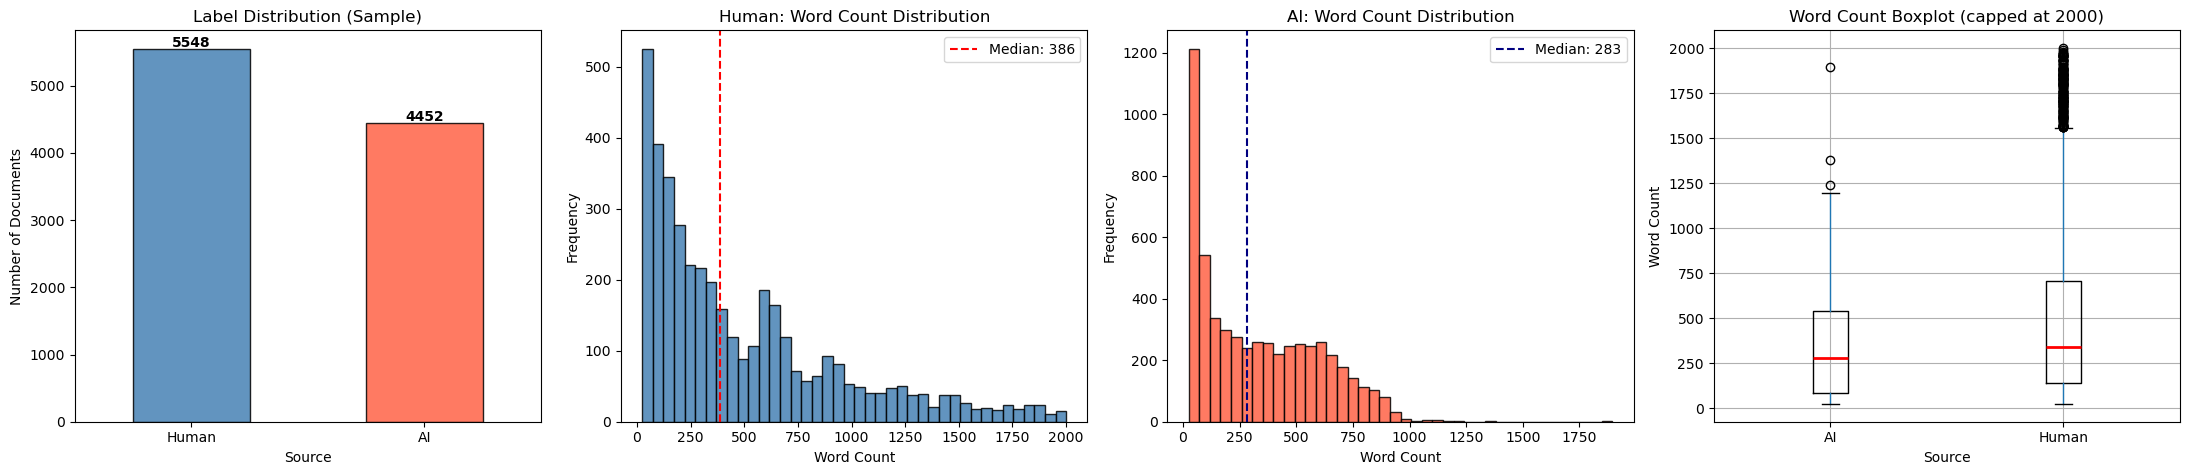

In [8]:
# Part 3: Visualizations 

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Corpus Statistics: Human vs. AI Text', fontsize=14, fontweight='bold')

# Plot 1: Label distribution bar chart
label_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'],
                  edgecolor='black', alpha=0.85)
axes[0].set_title('Label Distribution (Sample)')
axes[0].set_xlabel('Source')
axes[0].set_ylabel('Number of Documents')
axes[0].set_xticklabels(['Human', 'AI'], rotation=0)
for i, v in enumerate(label_counts):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Plot 2: Word count histogram -- Human only
cap = 2000
human_wc = ai_human_df_sample[ai_human_df_sample['label'] == 0]['word_count']
axes[1].hist(human_wc[human_wc <= cap], bins=40, color='steelblue', 
             edgecolor='black', alpha=0.85)
axes[1].set_title('Human: Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(human_wc.median(), color='red', linestyle='--', 
                label=f'Median: {human_wc.median():.0f}')
axes[1].legend()

# Plot 3: Word count histogram -- AI only
ai_wc = ai_human_df_sample[ai_human_df_sample['label'] == 1]['word_count']
axes[2].hist(ai_wc[ai_wc <= cap], bins=40, color='tomato', 
             edgecolor='black', alpha=0.85)
axes[2].set_title('AI: Word Count Distribution')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')
axes[2].axvline(ai_wc.median(), color='navy', linestyle='--', 
                label=f'Median: {ai_wc.median():.0f}')
axes[2].legend()

# Plot 4: Boxplot of word counts by label
ai_human_df_sample['label_name'] = ai_human_df_sample['label'].map({0: 'Human', 1: 'AI'})
ai_human_df_sample[ai_human_df_sample['word_count'] <= cap].boxplot(
    column='word_count', by='label_name', ax=axes[3],
    boxprops=dict(color='black'),
    medianprops=dict(color='red', linewidth=2)
)
axes[3].set_title(f'Word Count Boxplot (capped at {cap})')
axes[3].set_xlabel('Source')
axes[3].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig('/Users/maddiemac/Desktop/INFO 230/cultural-analytics-project-1/figures/EDA_visuals')
plt.show()

### Notable observations from EDA
- Confirmed again: Label distribution is well-balanced (44.5% Human / 55.5% AI) — almost identical to the full dataset
    - confirming the sample is representative.
- Human text has a mean of 701 words but a LARGE standard deviation of 1,023
    - Indicating: humans write very inconsistently in length, from short responses to very long essays (max 23,392 words)
- AI text is much more consistent: mean 336 words, std only 279, max 5,019. 
    - Indicating: AI models tend to produce more uniform, moderate-length outputs

- Histograms: 
    - Contrast between Human and AI text is clear: 
        - Human text (median 386 words) is more spread out across the full range, with a gradual right-skewed tail extending well past 1,500 words
            - Suggests that humans produce everything from short responses to lengthy essays
        - AI text (median 283 words) has a dramatic spike in the 0–100 word range
            - Suggests many LLM generations are very short, before tapering off more sharply than human text
    - Both distributions are right-skewed, but AI's is far more extreme (in terms of skewness)

- Boxplot: 
    - Reveals something the histograms don't show as cleanly: the interquartile range (the box itself) for AI is actually narrower and lower than for Human
        - meaning the middle 50% of AI texts are concentrated in a tighter word count range (roughly 100–500 words)
        - Human text has a much taller box: confirms the larger variability in the typical human document 
            - Human boxplot also has far more outliers stacked above 1,500 words (the black dots) vs. AI outliers are fewer and less extreme
                - Reinforces that AI writing is more length-consistent while human writing is more length-diverse
                    - This is a finding that will directly motivate why fixed-length chunking may be the best strategy for this corpus in Step 3.
- Part(b)'s output shows the source diversity to be very high: 62 LLMs ranging from tiny models like Flan-T5-Small (mean 40 words) to large ones like Nous-Hermes-LLaMA-2-70B (mean 804 words)
    - <span style="color: red;">This heterogeneity will be discussed within limitations</span>
 

# Step 3: Chunking 
- Goal of chunking: break the documents into units suitable for topic modeling 
    - Topic modeling works best with chunks that are: 
        - (1) long enough to contain meaningful topical signal
        - (2) consistent enough in size so no single chunk dominates the model

- I will try and compare TWO strategies 
    - (Strategy 1): Document-level, i.e., treating each document as its own chunk (no splitting)
    - (Strategy 2): Fixed-length windows: split each document into 200-word chunks 

- Finally I will test both strategies using chunk size stats to justify which is more appropriate for this corpus and the topic modeling goals

In [12]:
# Chunking Strategy 1: Document-level chunking
    # simplest approach: each document is already a "chunk"
    # add chunk_id column

chunks_s1 = ai_human_df_sample[['text', 'source', 'label', 'word_count']].copy()
chunks_s1['doc_id'] = chunks_s1.index
chunks_s1['chunk_id'] = 0    # only one chunk per document

print("===Strategy 1: Document-Level Chunking===")
print(f"\t Total chunks: {len(chunks_s1):,}")
print(f"\t Mean chunk size: {chunks_s1['word_count'].mean():.1f} words")
print(f"\t Median chunk size: {chunks_s1['word_count'].median():.1f} words")
print(f"\t Stdev chunk size: {chunks_s1['word_count'].std():.1f} words")
print(f"\t Min chunk size: {chunks_s1['word_count'].min()} words")
print(f"\t Max chunk size: {chunks_s1['word_count'].max()} words")

# Chunking Strategy 2: Fixed-length word window chunking
    # each document is split into non-overlapping windows of CHUNK_SIZE words
        # NOTE: the final chunk of each document may be shorter than CHUNK_SIZE 
            # (minimum is 50 words) - otherwise discard the chunk to avoid tiny (low-signal) chunks

CHUNK_SIZE = 200    # words per chunk 
MIN_CHUNK_WORDS = 50

def chunk_by_words(text, chunk_size=CHUNK_SIZE, min_words=MIN_CHUNK_WORDS):
    """
    Split a text string into non-overlapping chunks of chunk_size words.
    Discards the final chunk if it has fewer than min_words words.
    Returns a list of chunk strings.
    """
    words  = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size):
        chunk = ' '.join(words[i:i + chunk_size])
        if len(chunk.split()) >= min_words:
            chunks.append(chunk)
    return chunks

# Apply chunking to every document in the sample
rows = []
for doc_id, row in ai_human_df_sample.iterrows():
    doc_chunks = chunk_by_words(row['text'])
    for chunk_idx, chunk_text in enumerate(doc_chunks):
        rows.append({
            'doc_id'    : doc_id,
            'chunk_id'  : chunk_idx,
            'text'      : chunk_text,
            'source'    : row['source'],
            'label'     : row['label'],
            'word_count': len(chunk_text.split())
        })

chunks_s2 = pd.DataFrame(rows)

print("\n===Strategy 2: Fixed-Length Word Window Chunking")
print(f"\t Chunk size setting: {CHUNK_SIZE} words (min: {MIN_CHUNK_WORDS})")
print(f"\t Total chunks: {len(chunks_s2):,}")
print(f"\t Mean chunk size: {chunks_s2['word_count'].mean():.1f} words")
print(f"\t Median chunk size: {chunks_s2['word_count'].median():.1f} words")
print(f"\t Stdev chunk size: {chunks_s2['word_count'].std():.1f} words")
print(f"\t Min chunk size: {chunks_s2['word_count'].min()} words")
print(f"\t Max chunk size: {chunks_s2['word_count'].max()} words")

# STRATEGY COMPARISON 
    #  A good chunking strategy for topic modeling should produce chunks that are:
        # (1) big enough (hundreds to thousands of chunks)
        # (2) consistent in size (low std relative to mean)
        # (3) long enough to carry topical signal (ideally 100-500 words)

# Use CV=stdev/mean (coefficient of variation) as a simple measure of size consistency 
    # lower CV = more uniform chunks 
cv_s1 = chunks_s1['word_count'].std() / chunks_s1['word_count'].mean()
cv_s2 = chunks_s2['word_count'].std() / chunks_s2['word_count'].mean()

print("\n===STRATEGY COMPARISON===")
print(f"{'Metric':<30} {'Strategy 1':>15} {'Strategy 2':>15}")
print(f"{'Total chunks':<30} {len(chunks_s1):>15,} {len(chunks_s2):>15,}")
print(f"{'Mean chunk size (words)':<30} {chunks_s1['word_count'].mean():>15.1f} {chunks_s2['word_count'].mean():>15.1f}")
print(f"{'Stdev chunk size (words)':<30} {chunks_s1['word_count'].std():>15.1f} {chunks_s2['word_count'].std():>15.1f}")
print(f"{'Coefficient of Variation':<30} {cv_s1:>15.3f} {cv_s2:>15.3f}")
print(f"{'Min chunk size (words)':<30} {chunks_s1['word_count'].min():>15} {chunks_s2['word_count'].min():>15}")
print(f"{'Max chunk size (words)':<30} {chunks_s1['word_count'].max():>15} {chunks_s2['word_count'].max():>15}")

===Strategy 1: Document-Level Chunking===
	 Total chunks: 10,000
	 Mean chunk size: 498.4 words
	 Median chunk size: 326.0 words
	 Stdev chunk size: 736.1 words
	 Min chunk size: 25 words
	 Max chunk size: 23392 words

===Strategy 2: Fixed-Length Word Window Chunking
	 Chunk size setting: 200 words (min: 50)
	 Total chunks: 27,430
	 Mean chunk size: 178.6 words
	 Median chunk size: 200.0 words
	 Stdev chunk size: 42.5 words
	 Min chunk size: 50 words
	 Max chunk size: 200 words

===STRATEGY COMPARISON===
Metric                              Strategy 1      Strategy 2
Total chunks                            10,000          27,430
Mean chunk size (words)                  498.4           178.6
Stdev chunk size (words)                 736.1            42.5
Coefficient of Variation                 1.477           0.238
Min chunk size (words)                      25              50
Max chunk size (words)                   23392             200


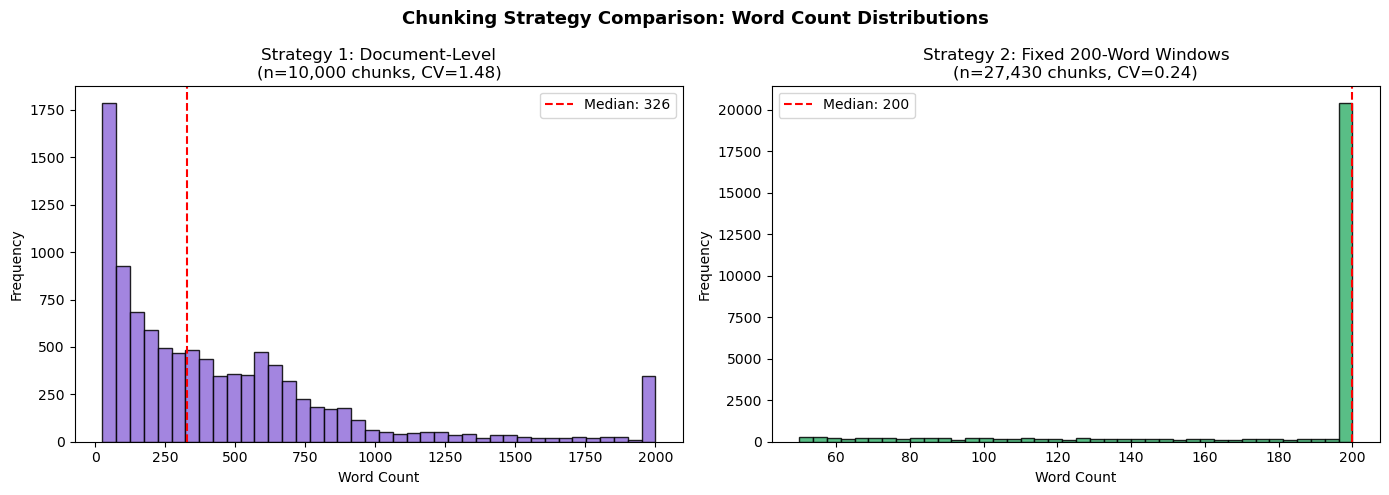

In [14]:
# Visualize the comparison between chunking strategies 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chunking Strategy Comparison: Word Count Distributions', 
             fontsize=13, fontweight='bold')

cap = 2000
# Strategy 1 histogram
axes[0].hist(chunks_s1['word_count'].clip(upper=cap), bins=40, 
             color='mediumpurple', edgecolor='black', alpha=0.85)
axes[0].axvline(chunks_s1['word_count'].median(), color='red', 
                linestyle='--', label=f"Median: {chunks_s1['word_count'].median():.0f}")
axes[0].set_title(f'Strategy 1: Document-Level\n(n={len(chunks_s1):,} chunks, CV={cv_s1:.2f})')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Strategy 2 histogram
axes[1].hist(chunks_s2['word_count'].clip(upper=cap), bins=40, 
             color='mediumseagreen', edgecolor='black', alpha=0.85)
axes[1].axvline(chunks_s2['word_count'].median(), color='red', 
                linestyle='--', label=f"Median: {chunks_s2['word_count'].median():.0f}")
axes[1].set_title(f'Strategy 2: Fixed 200-Word Windows\n(n={len(chunks_s2):,} chunks, CV={cv_s2:.2f})')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('/Users/maddiemac/Desktop/INFO 230/cultural-analytics-project-1/figures/chunking_strategies')
plt.show()


In [15]:
# prior to discussing which strategy is better 
    # save BOTH chunked datasets for later classification and topic modeling 
        # so its easy to load either strategy cleanly

chunks_s1.to_csv(os.path.join(data_dir, 'chunks_strategy1.csv'), index=False)
chunks_s2.to_csv(os.path.join(data_dir, 'chunks_strategy2.csv'), index=False)
print("\nSaved: chunks_strategy1.csv")
print("Saved: chunks_strategy2.csv")


Saved: chunks_strategy1.csv
Saved: chunks_strategy2.csv


## Chunking Strategy Comparison -  Interpretation and Decision: 

- Overall argument made here and supported by the explorations above:
    - Strategy 1 preserves document integrity (keeps the whole thing) but then has all that length variability seen in Step 2 (CV will be high, stdev high, high max ~23k words) 
    - (vs) Strategy 2 enforces consistency (CV will be much lower) which is what topic models need 
    
- Note that the coefficient of variation comparison is a quantitative test that proves this

### Detailed explanation of the above output (support for chunking strategy 2):

- Overall, the output supports that Strategy 2 (Fixed 200-Word Windows) is clearly the superior choice for topic modeling. Support from the data output above for this choice include: 

    - Chunk count: Strategy 2 produces 27,430 chunks vs. Strategy 1's 10,000
        - about 3x more data points for the topic model to learn from 
            - more chunks means more robust, stable topic distributions

    - Size consistency (most critical factor): Strategy 1 coefficient of variation is 1.477 meaning the standard deviation is larger than the mean, which indicates extreme inconsistency 
        - VS: Strategy 2 has VS of 0.238 (over 6x lower than strategy 1), which suggests highly uniform chunk sizes 
            - topic models in general typically assume documents are drawn from similar length distributions so widely varying chunk sizes would violate this assumption and bias the topics toward content merely from longer documents 

    - Comparing the extremes: 
        - Strategy 1's chunks range from just 25 words to 23,392 words (935x difference)
            - a 25-word chunk carries almost no topical signal, while a 23,392-word chunk will single-handedly dominate entire topics 
        - Strategy 2 keeps every chunk between 50 and 200 words which is a controlled, meaningful range

    - Visualization interpretation: 
        - Strategy 1 histogram is highly right-skewed with a wide spread across the full 0–2,000 word range, and that spike at 2,000 represents the many documents exceeding the cap (confirming extreme outliers)
        - Strategy 2's histogram tells the opposite story: an overwhelming spike at exactly 200 words (full chunks) with a small tail of shorter final chunks is exactly the behavior attempted to designed for
            - The tall vertical bar at 200 visually confirms how tightly controlled the chunk sizes are

### Conclusion: Proceed with Strategy 2 for topic modeling
- Strategy 1 will still be used later as a comparison in the advanced topic modeling section to demonstrate how chunking choice affects model output

# Step 4: Are there any existing labels for this data? 
- YES: dataset has a pre-existing binary label: Human (0) vs. AI (1)

## (i) Can we train a supervised learning method to apply these labels 
 - I will try to train a supervised classifier to see if text patterns alone can predict whether text was written by a human or generated by an LLM.
    - This is a binary classification task as defined in seminar: separating corpus into exactly two classes: Human vs. AI

### NOTE: I will use Strategy 2 chunks (fixed 200-word windows) as input since established (in previous step) these are more consistent and better suited for modeling 

## (ii) Check the (F1) score to see how well a supervised learner performs 
## (iii) Provide interpretation of why we get a certain F1 result 

###  General Workflow to satisfy all parts above: 
- (1) Vectorize text using TF-IDF
    -  TF-IDF (Term Frequency-Inverse Document Frequency): converts raw text into numerical features (i.e., words that are frequent in a document but rare across the full corpus get the highest weights) 
        - these are the most distinctive, informative words for classification

- (2) Split into train/test sets (80/20)
    - 80% of chunks used for training, 20% held out for testing

- (3) Train two classifiers from lecture: Logistic Regression + Naive Bayes
    - Model 1: Logistic Regression 
        - used for categorical outcome variables (works well for text classification)
        - fits a decision boundary in high-dimensional TF-IDF feature space
    - Model 2: Naive Bayes
        - A probabilistic classifier that treats each TF-IDF feature independently
        - Despite the "naive" independence assumption, it performs surprisingly well on text data and is very fast to train

- (4) Evaluate using F1 score, precision, recall, and confusion matrix
    - F1 = harmonic mean of precision and recall from seminar that macro-averaged F1 treats both classes equally regardless of size
    - Will also report per-class F1 to see if the model struggles more with one class than the other

- (5) Interpret results
    - (i) Visualize via confusion matrices: shows exactly where the model makes mistakes
        - i.e., which class is it confusing for the other?
            - rows = actual label, columns = predicted label, diagonal = correct predictions, off-diagonal = errors
    - (ii) Using top predictive features 
        - one advantage of Logistic Regression over Naive Bayes is interpretability (i.e., we can extract coefficients to see which words/bigrams are most strongly associated with Human vs. AI writing) 
            - This directly informs the interpretation of WHY the model performs as it does
                - Positive coefficients = predictive of AI (label=1)
                - Negative coefficients = predictive of Human (label=0)

Vectorizing text with TF-IDF...
	 TF-IDF matrix shape: (27430, 10000)
	 Vocabulary size: 10,000 terms

Train/Test Split:
	 Training chunks: 21,944
	 Test chunks: 5,486
	 Train label dist: {'Human': np.int64(13372), 'AI': np.int64(8572)}
	 Test label dist: {'Human': np.int64(3343), 'AI': np.int64(2143)}

Training Logistic Regression...
Training Naive Bayes...
===Classification Results===

 ---Logistic Regression---
	 Macro F1: 0.8617
	 F1 (Human): 0.8975
	 F1 (AI): 0.8260

	 Full Classification Report:
              precision    recall  f1-score   support

       Human       0.87      0.93      0.90      3343
          AI       0.87      0.78      0.83      2143

    accuracy                           0.87      5486
   macro avg       0.87      0.86      0.86      5486
weighted avg       0.87      0.87      0.87      5486


 ---Naïve Bayes---
	 Macro F1: 0.8163
	 F1 (Human): 0.8636
	 F1 (AI): 0.7690

	 Full Classification Report:
              precision    recall  f1-score   support

  

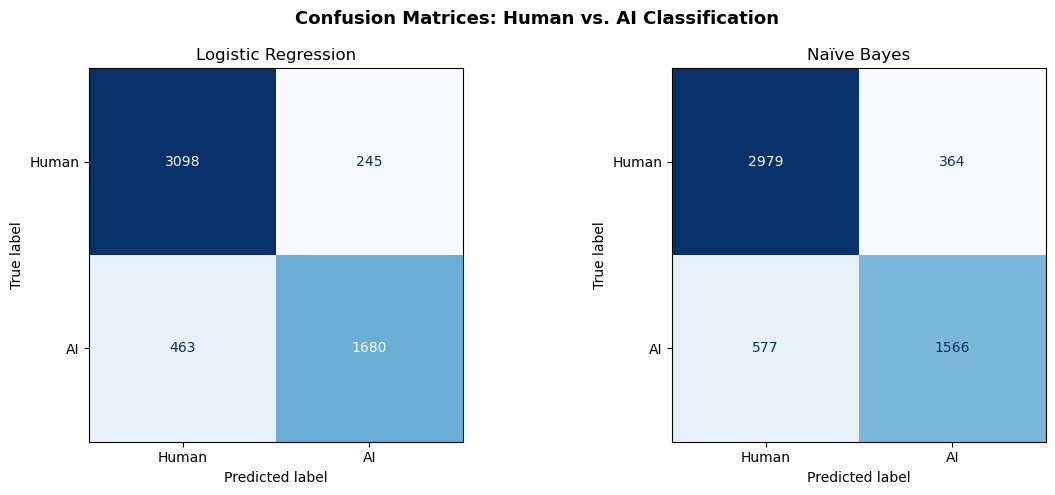


 ---Top 15 Features Predictive of AI Writing---
	 potential                      coef: 4.8588
	 including                      coef: 4.4700
	 significant                    coef: 3.6509
	 additionally                   coef: 3.3520
	 explore                        coef: 3.3417
	 substeps                       coef: 3.2471
	 lead                           coef: 3.2338
	 ultimately                     coef: 3.1907
	 complex                        coef: 3.1578
	 profound                       coef: 3.1359
	 impact                         coef: 3.1236
	 leading                        coef: 2.9941
	 challenges                     coef: 2.8166
	 known                          coef: 2.5934
	 traditional                    coef: 2.5857

 ---Top 15 Features Predictive of Human Writing---
	 case                           coef: -4.0546
	 organization                   coef: -3.7293
	 2009                           coef: -3.5122
	 web                            coef: -3.3551
	 essay              

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, f1_score, ConfusionMatrixDisplay, confusion_matrix)

# (Workflow 1): Vectorize Text with TF-IDF
print("Vectorizing text with TF-IDF...")
tfidf = TfidfVectorizer(
    max_features = 10000,   # limits vocabulary to top 10k terms (efficiency)
    min_df = 2,   # ignore words appearing in only 1 chunk (likely noise)
    max_df = 0.95,    # ignore words in 95%+ of chunks (too common to be useful)
    stop_words = 'english',   
    ngram_range = (1, 2)   # ngram_range=(1,2): include both single words AND two-word phrases
)

X = tfidf.fit_transform(chunks_s2['text'])
y = chunks_s2['label']

print(f"\t TF-IDF matrix shape: {X.shape}")
print(f"\t Vocabulary size: {len(tfidf.vocabulary_):,} terms")

# (Workflow 2): Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = RANDOM_SEED,
    stratify = y    # ensures both Human and AI are proportionally represented in both training and test sets (fair evaluation)
)

print(f"\nTrain/Test Split:")
print(f"\t Training chunks: {X_train.shape[0]:,}")
print(f"\t Test chunks: {X_test.shape[0]:,}")
print(f"\t Train label dist: {dict(y_train.value_counts().rename({0:'Human', 1:'AI'}))}")
print(f"\t Test label dist: {dict(y_test.value_counts().rename({0:'Human', 1:'AI'}))}")

# (Workflow 3): Train Classifiers

# Model 1: Logistic Regression 
print("\nTraining Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)    # max_iter=1000 ensures the optimizer converges on our large feature space
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Model 2: Naive Bayes
print("Training Naive Bayes...")
nb = MultinomialNB()    # MultinomialNB is specifically designed for count/frequency features like TF-IDF
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# (Workflow 4): Evaluate: F1 Score & Classification Report
print("===Classification Results===")
for model_name, y_pred in [("Logistic Regression", y_pred_lr), ("Naïve Bayes", y_pred_nb)]:
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_human = f1_score(y_test, y_pred, average=None)[0]
    f1_ai = f1_score(y_test, y_pred, average=None)[1]

    print(f"\n ---{model_name}---")
    print(f"\t Macro F1: {f1_macro:.4f}")
    print(f"\t F1 (Human): {f1_human:.4f}")
    print(f"\t F1 (AI): {f1_ai:.4f}")
    print(f"\n\t Full Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))

# (Workflow 5 - part 1): Interpret Results by visualizing with confusion matrices 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices: Human vs. AI Classification', fontsize=13, fontweight='bold')

for ax, y_pred, title in zip(axes, [y_pred_lr, y_pred_nb], ['Logistic Regression', 'Naïve Bayes']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('/Users/maddiemac/Desktop/INFO 230/cultural-analytics-project-1/figures/confusion_matrices')

plt.show()

# (Workflow 5 - part 2): Interpret Results through top predictive features (logistic regression)
feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]
top_n = 15

top_ai_idx = coefs.argsort()[-top_n:][::-1]
top_human_idx = coefs.argsort()[:top_n]

print("\n ---Top 15 Features Predictive of AI Writing---")
for i in top_ai_idx:
    print(f"\t {feature_names[i]:<30} coef: {coefs[i]:.4f}")

print("\n ---Top 15 Features Predictive of Human Writing---")
for i in top_human_idx:
    print(f"\t {feature_names[i]:<30} coef: {coefs[i]:.4f}")

# General Discussion of Step 4 Results 

## Overall Model Performance: 
- Logistic Regression achieved a macro F1 of 0.862 and Naive Bayes achieved 0.816. Both are strong results, i.e., well above random chance (0.5). This means TF-IDF features alone carry substantial signal for distinguishing human from AI writing. 
- Logistic Regression outperforms Naive Bayes on every metric, which makes sense given that Naive Bayes' independence assumption (treating every word as unrelated to every other word) is a simplification that costs it some predictive power.

## An Interesting Culture Question: Why is F1 not "perfect"? 
- An F1 of ~0.86 rather than ~0.99 is actually the expected and meaningful result. This is because:
    - This corpus combines 62 different LLMs with wildly different writing styles (e.g., from tiny models like Flan-T5-Small that generate 40-word responses to large models like GPT-4 that produce polished 600+ word essays)
        - Thus, some LLM outputs are nearly indistinguishable from human writing at the word-frequency level, which is exactly what makes AI detection a hard, open research problem. 
        
    - Additionally, the ~14% error rate reflects genuine linguistic overlap between human and AI text 
        - <span style ="color: red;">(will discuss further in limitations)</span>

## Why does the model do better on human vs AI (in terms of F score)?
- Logistic Regression scores F1=0.90 on Human but only F1=0.83 on AI. This asymmetry is meaningful. Human writing has higher variance in style, topic, and vocabulary (recall our corpus stats: stdev of 1,023 words vs. AI's 279), which (somewhat counterintuitive) makes it MORE distinctive as a class (i.e., its messiness, personal vocabulary, and distinctive patterns are hard for the model to confuse with AI). 
- Moreover, AI writing, while more consistent, is also more homogeneous across models in certain ways (structured, formal, moderate length), making individual AI chunks sometimes look human-like.
    - <span style ="color: red;">(will discuss further in limitations: worse writing = not human? Thats unfair)</span>

## Confusion Matrix Interpretation: 
- For Logistic Regression: of 3,343 actual Human chunks, 3,098 were correctly identified (93% recall) and only 245 were wrongly called AI. 
    - Of 2,143 actual AI chunks, 1,680 were correctly identified (78% recall) but 463 were wrongly called Human. 
        - So the model's main weakness is AI chunks being misclassified as Human, not the other way around. 
        - This tells us some AI-generated text is stylistically convincing enough to fool a word-frequency classifier.

- Naive Bayes shows the same pattern but amplified...even more AI chunks (577) get misclassified as Human, confirming it's the harder class to predict and that Logistic Regression handles it better.

## The MOST interesting part (from a cultural standpoint) - Top Features: 
- The predictive features tell an interesting cultural story, yet one that I will grapple more within limitations section. 

 - AI writing is flagged by words like "potential," "significant," "additionally," "ultimately," "challenges," "profound," "explore", meaning these are hallmark LLM vocabulary choices. 
    - Overall, AI models tend toward abstract, evaluative, and transitional language. 
    - They summarize, they conclude, they hedge. "Additionally" and "ultimately" are classic LLM connective tissue words that appear far less in natural human writing.
        -  <span style ="color: red;">So narrow and not true -- I learned the importance of using transitions in HIGHSCHOOL!</span>

- On the other hand, human writing is flagged by "case," "essay," "cited," "references," "people," "fact," "quite," "web" along with specific years like 2007, 2008, 2009. 
    - This is interesting regarding the suggested cultural idea that humans cite sources, reference real dates, use colloquialisms like "quite," and write in concrete situational terms ("case," "situation"). 
        - The year references also suggest human texts in this corpus include academic essays and web content written during a specific historical window, while LLM-generated texts are more generic in this regard. 

### Overall these results support a cultural analytics argument explored in this project: human and AI writing differ not just in style but in the relationship to time, evidence, and concrete reality. 
- <span style ="color: red;">Humans anchor their writing in specific facts, dates, and citations, while LLMs produce more generalized, rhetorically polished but contextually thin text.</span>

### <span style ="color: red;">Q: can we add any example visuals from the notebooks in this above step</span>

# Step 5: Running a single topic model and exploring the output 
- Advanced option: I will use 2 different models and 2 different chunking strategies (proviing explanations for the strategies and choices)

### <span style="color: red;">Don't forget:</span>
- other visualization options provided in the notebooks (such as interactive ones)
- Cite sources: confusion matrices 
- limitations: still not perfect, humans are writing more and more like AI even when they don't use it
    - theres only so many ways to phrase something 
    - predictor words lol can just be a high level of professional writing - like I learned transition words were good practice before AI was even a thing
        - also the more AI is around us the more its picked up on by humans and vice versa lol just like anything
    - AI is TRAINED ON US!!! where do you think they got the knowledge of how to write....